<div align="center">
  <img src="https://www.rdkit.org/docs/_static/logo.png" alt="RDKit" width="300"><br>
  <sub>RDKit — Open-Source Cheminformatics Toolkit</sub>
</div>

# RDKit Practice Notebook

### Drug Discovery & Cheminformatics Workflow

---

## Overview

This notebook provides a comprehensive, hands-on guide to **RDKit**, an open-source cheminformatics toolkit widely used across pharmaceutical and computational chemistry research.

**Core applications covered:**

| Area | Description |
|---|---|
| Molecular Structure Analysis | Parsing, visualizing, and manipulating chemical structures |
| Drug Discovery | Lead identification, similarity search, and scaffold analysis |
| Molecular Property Calculation | Descriptors, physicochemical properties, and ADMET-relevant features |
| Machine Learning Integration | Molecular featurization for predictive modeling |
| QSAR Modeling | Structure–activity relationship analysis |
| Graph Neural Networks | Molecular graph representations for GNN-based architectures |



## Learning Roadmap

1. Introduction to RDKit & Molecule Objects
2. SMILES/SMARTS Parsing and Molecular I/O
3. 2D/3D Structure Visualization
4. Molecular Descriptors & Property Calculation
5. Substructure Search and Fingerprinting
6. Similarity Analysis
7. QSAR Model Building
8. ML/GNN Integration for Molecular Prediction



## Complete RDKit Practice Notebook — Drug Discovery & Cheminformatics

| # | Section | Focus |
|---|---------|-------|
| 1 | Installation | Environment setup and dependencies |
| 2 | Molecule Representation | RDKit `Mol` object fundamentals |
| 3 | SMILES / MOL / SDF | Molecular file formats and I/O |
| 4 | Molecular Descriptors | Physicochemical property calculation |
| 5 | Lipinski's Rule of Five | Drug-likeness filtering |
| 6 | Fingerprints | Molecular fingerprint generation (Morgan, MACCS, etc.) |
| 7 | Similarity Search | Tanimoto and other similarity metrics |
| 8 | Substructure Search | SMARTS pattern matching |
| 9 | Molecular Filtering | ADMET / PAINS / structural alert filtering |
| 10 | Conformer Generation | 3D structure embedding and optimization |
| 11 | Scaffold Analysis | Murcko scaffold decomposition |
| 12 | Chemical Reactions | Reaction SMARTS and transformation modeling |
| 13 | QSAR Machine Learning | Structure–activity relationship modeling |
| 14 | Graph Neural Networks | GNN-based molecular property prediction |
| 15 | Drug Discovery Pipeline | End-to-end integrated workflow |




### Module 1: Installation

In [7]:
! pip install rdkit
# or
# !conda install -c conda-forge rdkit


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


### Module 2: Imports
This is almost every import you'll repeatedly use.

In [8]:
import rdkit
print(rdkit.__version__)

from rdkit import Chem
from rdkit import DataStructs

from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Crippen
from rdkit.Chem import Lipinski
from rdkit.Chem import Fragments
from rdkit.Chem import BRICS
from rdkit.Chem import MACCSkeys
from rdkit.Chem import PandasTools
from rdkit.Chem import rdFMCS
from rdkit.Chem import Recap
from rdkit.Chem import rdDepictor
from rdkit.Chem import rdMolAlign
from rdkit.Chem import rdChemReactions


from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.Draw import IPythonConsole


import pandas as pd
import numpy as np

2026.03.3


# RDKit Chem Submodules Reference

```python
from rdkit.Chem import (
    rdMolInterchange,
    rdMolTransforms,
    rdMolCatalog,
    rdMolAlign,
    rdMolEnumerator,
    rdMolHash,
    rdMolProcessing,
    rdMolDescriptors,
    rdChemicalFeatures
)
```

## Module Reference

| Module | Purpose |
|---|---|
| `rdMolDescriptors` | Molecular descriptors (MW, LogP, TPSA, etc.) |
| `rdMolAlign` | Molecule alignment (3D similarity) |
| `rdMolTransforms` | 3D coordinate transformation |
| `rdMolEnumerator` | Enumerate possible molecular variants |
| `rdMolHash` | Generate molecular hashes |
| `rdChemicalFeatures` | Chemical features (H-bond donor/acceptor, pharmacophore) |
| `rdMolInterchange` | Molecule serialization/conversion |
| `rdMolCatalog` | Molecule catalog/substructure searching |
| `rdMolProcessing` | Molecule processing utilities |

## Most used in drug discovery workflows

- `rdMolDescriptors`
- `rdMolAlign`
- `rdChemicalFeatures`
- `rdMolHash`

## What is Molecular Descriptors?

In cheminformatics, a molecular descriptor is a numerical value that describes a chemical molecule's properties. RDKit calculates these properties from a molecule structure (usually from SMILES). Machine learning models cannot directly understand chemical structures.

**So we convert:**
- SMILES → Molecule → Molecular Descriptors → Numbers → Machine Learning Model.


**A molecule is a graph:**
- Atoms + Bonds → Molecular Structure



---

```python
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin
```

## Why it matters
```
SMILES → Molecule → Descriptors (numbers) → ML model features
```
ML can't read chemical structures directly — descriptors are the bridge.

## Core Functions (cheat sheet)

| Function | Meaning | Aspirin Example |
|---|---|---|
| `CalcExactMolWt(mol)` | Molecular weight | 180.04 |
| `CalcNumAtoms(mol)` | Total atom count | — |
| `CalcNumHeavyAtoms(mol)` | Atoms excluding H | — |
| `CalcNumHBD(mol)` | H-bond donors (OH, NH) | 1 |
| `CalcNumHBA(mol)` | H-bond acceptors (O, N) | 4 |
| `CalcTPSA(mol)` | Polar surface area → absorption/permeability | 63.6 |
| `CalcNumRotatableBonds(mol)` | Molecule flexibility | 3 |
| `CalcNumRings(mol)` | Total ring count | — |
| `CalcNumAromaticRings(mol)` | Aromatic ring count | — |
| `CalcFractionCSP3(mol)` | Fraction of sp3 carbons → 3D character | — |

## Memory hooks
- **HBD/HBA** → Lipinski's Rule of 5, drug-likeness
- **TPSA** → predicts if drug crosses cell membranes
- **Rotatable bonds** → flexibility → binding entropy
- **FractionCSP3** → "flat" (aromatic-heavy) vs "3D-shaped" molecule
- **Ring count / aromatic rings** → structural rigidity, metabolic stability

## One-line summary
> `rdMolDescriptors` = molecule → property numbers → drug-likeness & ML features.


| Function                 | Input          | Output                  | Purpose                          | When to Use                           |
| ------------------------ | -------------- | ----------------------- | -------------------------------- | ------------------------------------- |
| `Chem.MolFromSmiles()`   | SMILES string  | RDKit Mol object        | Convert SMILES into a molecule   | Whenever your data is in SMILES       |
| `Chem.MolToSmiles()`     | Mol object     | SMILES string           | Convert molecule back to SMILES  | Save, compare, canonicalize molecules |
| `Chem.MolFromMolFile()`  | MOL file       | Mol object              | Read molecule from .mol file     | Working with MDL Mol files            |
| `Chem.MolToMolFile()`    | Mol object     | MOL file                | Save molecule as .mol            | Export for chemistry software         |
| `Chem.SDMolSupplier()`   | SDF file       | Iterable of Mol objects | Read many molecules              | Dataset processing                    |
| `Chem.SDWriter()`        | Mol objects    | SDF file                | Write many molecules             | Save datasets                         |
| `Chem.MolToMolBlock()`   | Mol object     | MOL block text          | Convert to text representation   | APIs, databases, copy/paste           |
| `Chem.MolFromMolBlock()` | MOL block text | Mol object              | Read MolBlock text               | APIs returning MOL block              |
| `Chem.MolToInchi()`      | Mol object     | InChI string            | Generate standardized identifier | Database matching                     |
| `Chem.MolFromInchi()`    | InChI string   | Mol object              | Rebuild molecule from InChI      | Import standardized structures        |


## Explanations — Core RDKit Imports

### Complete Import Block

```python
# Core RDKit
import rdkit
from rdkit import Chem
from rdkit import DataStructs

# Molecule Generation & Manipulation
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor
from rdkit.Chem import rdMolAlign

# Molecular Descriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Crippen
from rdkit.Chem import Lipinski
from rdkit.Chem import Fragments

# Fingerprints & Similarity
from rdkit.Chem import MACCSkeys

# Scaffold & Fragment Analysis
from rdkit.Chem import BRICS
from rdkit.Chem import Recap
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFMCS

# Chemical Reactions
from rdkit.Chem import rdChemReactions

# Data Handling
from rdkit.Chem import PandasTools
import pandas as pd
import numpy as np

# Jupyter Notebook Visualization
from rdkit.Chem.Draw import IPythonConsole
```

### Core RDKit

| Import | Purpose |
|---|---|
| `import rdkit` | Main RDKit library (check version) |
| `from rdkit import Chem` | Create, read, edit, and manipulate molecules |
| `from rdkit import DataStructs` | Molecular similarity (Tanimoto, Dice, Cosine) |



### Molecule Generation & Manipulation

| Import | Purpose |
|---|---|
| `from rdkit.Chem import AllChem` | Fingerprints, 3D conformers, force fields, advanced chemistry |
| `from rdkit.Chem import Draw` | Draw and visualize molecules |
| `from rdkit.Chem import rdDepictor` | Generate clean 2D coordinates |
| `from rdkit.Chem import rdMolAlign` | Align molecules and calculate RMSD |



### Molecular Descriptors

| Import | Purpose |
|---|---|
| `from rdkit.Chem import Descriptors` | Molecular weight, TPSA, rotatable bonds, etc. |
| `from rdkit.Chem import rdMolDescriptors` | Advanced molecular descriptors |
| `from rdkit.Chem import Crippen` | LogP and molar refractivity |
| `from rdkit.Chem import Lipinski` | Rule of Five descriptors |
| `from rdkit.Chem import Fragments` | Functional group detection |



### Fingerprints & Similarity

| Import | Purpose |
|---|---|
| `from rdkit.Chem import MACCSkeys` | MACCS fingerprints (166-bit) |
| `DataStructs` *(already imported above)* | Tanimoto, Dice, Cosine similarity |



### Scaffold & Fragment Analysis

| Import | Purpose |
|---|---|
| `from rdkit.Chem import BRICS` | BRICS fragmentation (fragment-based drug design) |
| `from rdkit.Chem import Recap` | RECAP fragmentation |
| `from rdkit.Chem.Scaffolds import MurckoScaffold` | Bemis–Murcko scaffold extraction |
| `from rdkit.Chem import rdFMCS` | Maximum Common Substructure (MCS) |



### Chemical Reactions

| Import | Purpose |
|---|---|
| `from rdkit.Chem import rdChemReactions` | Simulate chemical reactions |



### Data Handling

| Import | Purpose |
|---|---|
| `from rdkit.Chem import PandasTools` | Store and display molecules in pandas DataFrames |
| `import pandas as pd` | Data analysis and tabular manipulation |
| `import numpy as np` | Numerical computing |



### Jupyter Notebook Visualization

| Import | Purpose |
|---|---|
| `from rdkit.Chem.Draw import IPythonConsole` | Automatically render molecules inline in notebooks |

### Most Essential Imports (used in ~90% of RDKit projects)

In [9]:
import rdkit

from rdkit import Chem
from rdkit import DataStructs

from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit.Chem import Crippen
from rdkit.Chem import Lipinski

import pandas as pd
import numpy as np

For Drug discovery?
- **BRICS** → Fragment-based drug discovery
- **Recap** → Fragment analysis
- **MurckoScaffold** → Scaffold extraction
- **rdFMCS** → Common substructure search
- **rdChemReactions** → Reaction simulation
- **rdMolAlign** → Molecular alignment
- **rdMolDescriptors** → Advanced descriptors

### Module 3: Read Molecules
```
SMILES
SDF
Mol2
PDB
CSV

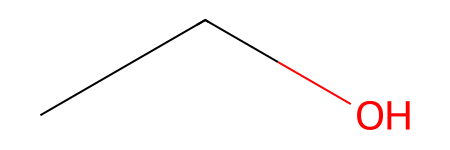

In [10]:
mol = Chem.MolFromSmiles("CCO")
mol

Read SDF

In [12]:
from rdkit import Chem

mols = [
    Chem.MolFromSmiles("CCO"),
    Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
]

writer = Chem.SDWriter("molecules.sdf")

for mol in mols:
    writer.write(mol)

writer.close()

In [13]:
supplier = Chem.SDMolSupplier("molecules.sdf")

mols = [m for m in supplier if m]

len(mols)

2

CSV

In [ ]:
# df = pd.read_csv("molecules.csv")
# mols = [Chem.MolFromSmiles(s) for s in df.SMILES]


### Module 4: Draw Molecules
Single

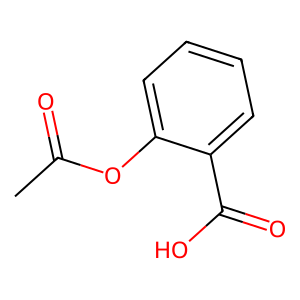

In [14]:
Draw.MolToImage(mol)

Grid

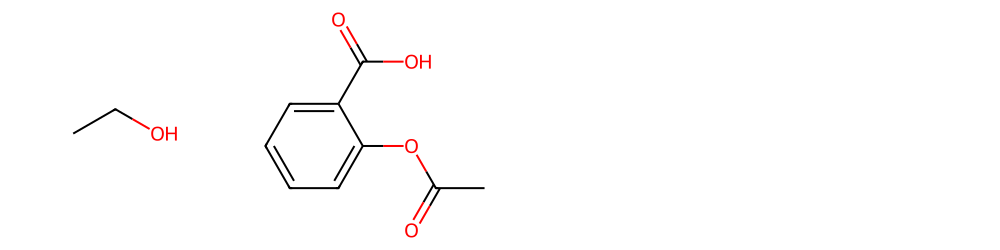

In [15]:
Draw.MolsToGridImage(
    mols[:16],
    molsPerRow=4,
    subImgSize=(250,250)
)


### Module 5: Basic Molecular Information

In [ ]:
print(mol.GetNumAtoms())
print(mol.GetNumBonds())
print(Chem.MolToSmiles(mol))
print(Chem.MolToInchi(mol))
print(Chem.MolToMolBlock(mol))


### Module 6: Molecular Descriptors
Calculate hundreds of descriptors.


| RDKit Function                         | Full Name                                       | What it Calculates                                                   | Example Meaning                                      |
| -------------------------------------- | ----------------------------------------------- | -------------------------------------------------------------------- | ---------------------------------------------------- |
| `Descriptors.MolWt(mol)`               | **Molecular Weight (Average Molecular Weight)** | Calculates the average molecular weight of the molecule              | Total atomic mass considering average isotope masses |
| `Descriptors.TPSA(mol)`                | **Topological Polar Surface Area**              | Calculates polar surface area based on molecular topology            | Indicates polarity and hydrogen bonding ability      |
| `Descriptors.NumRotatableBonds(mol)`   | **Number of Rotatable Bonds**                   | Counts freely rotating single bonds                                  | Indicates molecular flexibility                      |
| `Descriptors.HeavyAtomCount(mol)`      | **Heavy Atom Count**                            | Counts all non-hydrogen atoms                                        | Size/complexity of molecule                          |
| `Descriptors.NumValenceElectrons(mol)` | **Number of Valence Electrons**                 | Counts total valence electrons from all atoms                        | Useful for electronic properties                     |
| `Descriptors.RingCount(mol)`           | **Number of Rings**                             | Counts total rings in the molecule                                   | Measures cyclic structure complexity                 |
| `Descriptors.FractionCSP3(mol)`        | **Fraction of sp³ Hybridized Carbons**          | Calculates percentage of carbon atoms that are sp³ hybridized        | Indicates 3D character of molecule                   |
| `Descriptors.ExactMolWt(mol)`          | **Exact Molecular Weight**                      | Calculates exact molecular weight using most abundant isotope masses | More precise molecular mass                          |


In [ ]:
print(Descriptors.MolWt(mol))
print(Descriptors.TPSA(mol))
print(Descriptors.NumRotatableBonds(mol))
print(Descriptors.HeavyAtomCount(mol))
print(Descriptors.NumValenceElectrons(mol))
print(Descriptors.RingCount(mol))
print(Descriptors.FractionCSP3(mol))
print(Descriptors.ExactMolWt(mol))


### Module 7: Lipinski Rule of Five

In [ ]:
print(Lipinski.NumHDonors(mol))
print(Lipinski.NumHAcceptors(mol))
print(Crippen.MolLogP(mol))
print(Descriptors.MolWt(mol))
print(Descriptors.TPSA(mol))

# Create automatic Rule of Five checker.


### Module 8: Molecular Fingerprints
Morgan
MACCS
Topological
RDKit Fingerprint

Morgan

In [ ]:
fp_morgan = AllChem.GetMorganFingerprintAsBitVect(
    mol,
    radius=2,
    nBits=2048
)

MACCS

In [ ]:
fp_maccs = MACCSkeys.GenMACCSKeys(mol)

RDKit

In [ ]:
fp_rdkit = Chem.RDKFingerprint(mol)


### Module 9: Similarity
Tanimoto
Dice
Cosine

In [ ]:
mol1 = Chem.MolFromSmiles("CCO")
mol2 = Chem.MolFromSmiles("CCC")
fp1 = AllChem.GetMorganFingerprintAsBitVect(mol1,2)
fp2 = AllChem.GetMorganFingerprintAsBitVect(mol2,2)

print(DataStructs.TanimotoSimilarity(fp1,fp2))

Similarity Matrix
Nearest Neighbor Search


### Module 10: Molecular Properties
Calculate MW, LogP, TPSA, HBA, HBD, Rotatable Bonds, Heavy Atoms, Formal Charge, Aromatic Rings, FractionCSP3
Store in dataframe.


### Module 11: Functional Groups

In [ ]:
print(Fragments.fr_benzene(mol))
print(Fragments.fr_amide(mol))
print(Fragments.fr_ester(mol))
print(Fragments.fr_ketone(mol))
print(Fragments.fr_amine(mol))


### Module 12: SMARTS Search
Find Alcohol, Amide, Ketone, Aromatic ring

In [ ]:
pattern = Chem.MolFromSmarts("C=O")
print(mol.HasSubstructMatch(pattern))


### Module 13: Substructure Search
Highlight atoms.

In [ ]:
matches = mol.GetSubstructMatches(pattern)


### Module 14: Molecular Scaffold
Murcko Scaffold
Scaffold Network
Scaffold Analysis

In [ ]:
MurckoScaffold.GetScaffoldForMol(mol)


### Module 15: BRICS Fragmentation
Useful for Drug optimization, Fragment Based Drug Discovery

In [ ]:
# brics_fragments = BRICS.BRICSDecompose(mol)
# print(brics_fragments)


### Module 16: RECAP Decomposition

In [ ]:
# recap_fragments = Recap.RecapDecompose(mol)


### Module 17: Molecular Alignment
3D Alignment

In [ ]:
AllChem.Compute2DCoords(mol)


### Module 18: Conformer Generation
Generate 3D molecule

In [ ]:
mol_3d = Chem.AddHs(mol)
AllChem.EmbedMolecule(mol_3d)
AllChem.MMFFOptimizeMolecule(mol_3d)

Multiple conformers

In [ ]:
AllChem.EmbedMultipleConfs(
    mol_3d,
    numConfs=20
)


### Module 19: Force Field Optimization
UFF, MMFF94

In [ ]:
AllChem.UFFOptimizeMolecule(mol_3d)
# or
AllChem.MMFFOptimizeMolecule(mol_3d)


### Module 20: Pharmacophore Features
Extract Donor, Acceptor, Hydrophobic, Positive, Negative, Aromatic


### Module 21: Molecular Reaction
Reaction SMARTS
Run reaction

In [ ]:
rxn = rdChemReactions.ReactionFromSmarts(
    "[C:1]=O>>[C:1]O"
)


### Module 22: Descriptor Dataset
Generate descriptors for ML

In [ ]:
# descriptor_list = []
# for m in mols:
#     if m is not None:
#         descriptor_list.append({
#             "MW":Descriptors.MolWt(m),
#             "TPSA":Descriptors.TPSA(m),
#             "LogP":Crippen.MolLogP(m)
#         })
# df = pd.DataFrame(descriptor_list)


### Module 23: Fingerprint Dataset
Convert molecules into ML features

SMILES -> Mol -> Fingerprint -> X matrix -> RandomForest / XGBoost / Deep Learning


### Module 24: Diversity Analysis
Cluster molecules

- Butina clustering
- Similarity matrix
- Representative compounds


### Module 25: Duplicate Removal
Canonical SMILES

In [ ]:
Chem.MolToSmiles(
    mol,
    canonical=True
)


### Module 26: Molecular Standardization
Remove salts
Normalize
Neutralize
Canonicalize


## Module 27: PAINS Filter
Find problematic compounds.


## Module 28: Drug-likeness
Calculate: QED, SA Score, Lipinski, Veber, Ghose, Egan, Muegge


## Module 29: Export
Save: CSV, SMILES, SDF, Mol, PNG, SVG


## Module 30: End-to-End Mini Drug Discovery Pipeline

Load ChEMBL Dataset -> Read SMILES -> Remove Invalid Molecules -> Standardize Molecules -> Generate Descriptors -> Generate Fingerprints -> Calculate Lipinski -> Filter Drug-like Molecules -> Similarity Search -> Scaffold Analysis -> BRICS Fragmentation -> 3D Conformer Generation -> Energy Minimization -> Export Dataset -> Machine Learning -> QSAR Model -> Virtual Screening -> Molecular Docking -> ADMET Prediction -> Lead Optimization


## Additional topics worth adding

To make your RDKit notebook closer to what is used in research labs and pharmaceutical companies, also include:

* **Molecule standardization** using `rdMolStandardize` (remove salts, normalize, neutralize, choose largest fragment).
* **Descriptor calculation at scale** (all RDKit descriptors using `Descriptors._descList`).
* **Bemis–Murcko scaffold splitting** for machine learning train/validation/test sets.
* **Butina clustering** for chemical diversity analysis.
* **Maximum Common Substructure (MCS)** using `rdFMCS`.
* **Shape and pharmacophore similarity**.
* **SDF ↔ SMILES ↔ PDB conversions**.
* **Reaction enumeration** for library generation.
* **Integration with DeepChem, PyTorch Geometric, and DGL** by converting molecules into graph representations.
* **Preparation of ligands for docking** (generate 3D coordinates, optimize geometry, export SDF/MOL2/PDB formats for tools like AutoDock Vina).

## Recommended learning order

1. Molecule I/O (SMILES, SDF, PDB)
2. Visualization
3. Molecular descriptors
4. Lipinski and drug-likeness rules
5. Fingerprints and similarity search
6. SMARTS and substructure searching
7. Scaffold analysis
8. Fragmentation (BRICS, RECAP)
9. 3D conformer generation and geometry optimization
10. Dataset preparation for QSAR and machine learning
11. Virtual screening
12. Docking preparation
13. ADMET feature generation
14. Lead optimization